<a href="https://colab.research.google.com/github/Maria-lin/F1-Analytics/blob/main/detection_anomalies_gab_v11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏧 Détection d'Anomalies sur le Réseau GAB — Analyse Journalière
## Identification automatique des comportements atypiques sur les Guichets Automatiques Bancaires

---

> **Destinataires :** Experts métier – Responsables réseau GAB
> **Objectif :** Identifier automatiquement les GAB au comportement inhabituel, sans étiquette préalable
> **Approche :** Détection d'anomalies non supervisée (Isolation Forest) + Clustering comportemental (K-Means / Agglomératif / Gaussian Mixture)
> **Maille d'analyse :** **Journalière** (1 ligne = 1 GAB × 1 jour), avec agrégation multi-échelle semaine → mois → année

---

## Ce qui change par rapport à la version précédente

La version précédente de ce notebook analysait le comportement des GAB à la **maille mensuelle** : 1 ligne = 1 GAB × 1 mois. Cette approche a une limite structurelle : **un GAB peut présenter un comportement anormal sur une seule journée** (incident technique, fraude ponctuelle, panne) **sans que cela soit visible une fois moyenné sur 30 jours**. L'anomalie se noie dans la moyenne mensuelle.

Le système source (`fiche_identite_gab`) est désormais alimenté à la **maille journalière**. Cette évolution permet de :

1. Analyser le comportement quotidien de chaque GAB.
2. Détecter les journées atypiques, même isolées.
3. Comparer ces comportements sur plusieurs échelles temporelles (semaine, mois, année).
4. Distinguer les **anomalies ponctuelles** (un incident isolé, 1 à 3 jours) des **comportements durablement atypiques** (une dérive qui s'installe sur plusieurs semaines).
5. Construire des **familles comportementales stables** (clustering) mieux séparées qu'avant.

## ⚠️ Structure des données — alignée sur `ficheidentité.sql`

Ce notebook reproduit **exactement** les colonnes produites par la requête SQL de production (`ficheidentité.sql`), notamment :

- **Pas de colonne date** : la table réelle expose `annee`, `mois`, `jours` (jour du mois, 1-31) séparément — **aucune colonne `date` ni `date_iso` n'existe dans la vraie table**. Ce notebook reconstruit une colonne technique interne (préfixée `_`, ex. `_date_travail`) uniquement pour ses propres besoins de calcul (tri chronologique, jour de semaine, semaine ISO) — cette colonne **n'existe pas** et ne doit **jamais** être exportée vers Dataiku.
- **Distinction COS / hors-COS** systématique : `ret_nb` (retraits total, COS + hors-COS), `ret_nb_cos` et `ret_nb_horscos` séparés ; `cap_nb` (captures hors-COS), `cap_cos_nb` et `taux_capture_cos_pct` isolés.
- **Motifs de capture détaillés** (hors-COS) : oubli/incident lecture, code confidentiel dépassé, carte perdue, carte volée, autre motif, motif inconnu.
- **16 catégories de réseaux réelles** : Franfinance, CB, Trionis, PPL, Mastercard, Cofinoga, Interne, Casino, Accord, Amex, Visa, COS, JCB, Postépargne, Carte Diners et Discovery, Carte CUP, Autres.


## 1. ⚙️ Imports et Configuration

Ce notebook est conçu pour tourner sous **Dataiku DSS**, kernel Python 3.6, avec les versions suivantes (vérifiées en environnement de production) : **pandas 1.1.5** et **scikit-learn 0.21.1**.

⚠️ Toutes les fonctions utilisées ci-dessous sont disponibles nativement à ces versions. En particulier :
- Pas de `HDBSCAN` natif (introduit en scikit-learn 1.3, 2023) → nous comparons `KMeans`, `AgglomerativeClustering` et `GaussianMixture`, tous disponibles depuis longtemps.
- Pas de paramètre `sparse_output=` sur `OneHotEncoder` (introduit en 1.2) → non utilisé ici.
- `IsolationForest`, `silhouette_score`, `calinski_harabasz_score`, `davies_bouldin_score` sont stables depuis scikit-learn 0.20-0.21.


In [1]:
# ── Librairies ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

# ── Configuration graphique ───────────────────────────────────────────────────
plt.rcParams['figure.facecolor']  = 'white'
plt.rcParams['axes.facecolor']    = 'white'
sns.set_style('whitegrid')

COULEUR_NORMAL    = '#2E7D32'   # vert
COULEUR_PONCTUEL  = '#F9A825'   # orange
COULEUR_RECURRENT = '#C62828'   # rouge
COULEUR_ANOMALIE  = '#C62828'

RNG_SEED = 42
np.random.seed(RNG_SEED)

print('✅ Environnement chargé — pandas', pd.__version__)
import sklearn
print('✅ scikit-learn', sklearn.__version__)


✅ Environnement chargé — pandas 2.2.3
✅ scikit-learn 1.7.2


## 2. 🏗️ Génération du Dataset Journalier Synthétique

⚠️ **Aucune donnée bancaire réelle n'est utilisée.** Pour des raisons de confidentialité, nous générons un dataset **fictif mais statistiquement réaliste**, à la maille **1 ligne = 1 GAB × 1 jour**, sur ~912 jours (2024-01-01 → 2026-06-30), pour ~120 GAB en **France métropolitaine uniquement**.

Ce générateur reproduit **exactement** les colonnes de sortie de la requête SQL de production (`ficheidentité.sql`) :

- Clés : `num_automate, annee, mois, jours` — **pas de colonne date**, conformément à la vraie table.
- Retraits COS/hors-COS séparés (`ret_nb_cos`, `ret_nb_horscos`), captures hors-COS (`cap_nb`) et COS isolées (`cap_cos_nb`, `taux_capture_cos_pct`).
- Motifs de capture détaillés, 16 catégories de réseaux réelles.

### Trois régimes comportementaux distincts injectés

| Régime | % des GAB | Description |
|---|---|---|
| 🟢 **STABLE** | 80% | Comportement normal, avec une **famille structurelle légitime** (urbain dense, urbain standard, touristique) qui influence son profil de façon permanente. |
| 🟡 **PONCTUEL** | 10% | 2 à 4 incidents isolés de 1 à 3 jours sur toute la période. |
| 🔴 **RÉCURRENT** | 10% | 1 à 2 fenêtres de dérive continue de 4 à 10 semaines. |

Un label caché (`anomalie_synthetique_type`, `anomalie_synthetique_regime_gab`) trace ces injections, utilisé **uniquement** en section de validation pédagogique (7bis) — jamais dans le feature engineering ni la modélisation.


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# Génération du dataset journalier — structure exacte de ficheidentité.sql
# ══════════════════════════════════════════════════════════════════════════════
#
# En production Dataiku (décommenter) :
# import dataiku
# df = dataiku.Dataset('fiche_identite_gab_journalier').get_dataframe()

np.random.seed(RNG_SEED)

N_GAB = 120
# Colonne technique interne UNIQUEMENT — la vraie table n'a pas de colonne date,
# seulement annee/mois/jours séparés. On reconstruit une date ici pour trier et
# calculer jour de semaine / semaine ISO, exactement comme le fait la sous-requête
# SQL en interne avec `date_iso` (qui ne sort jamais dans la table finale).
_DATES = pd.date_range('2024-01-01', '2026-06-30', freq='D')
N_JOURS = len(_DATES)

# ── Contextes géographiques — Métropole uniquement ───────────────────────────
CONTEXTES_GEO = {
    '75001': {'lat': 48.860, 'lon':  2.347, 'base': 32, 'sig': 5.0, 'type': 'urbain_dense'},
    '69001': {'lat': 45.764, 'lon':  4.835, 'base': 24, 'sig': 4.0, 'type': 'urbain_dense'},
    '13001': {'lat': 43.297, 'lon':  5.381, 'base': 26, 'sig': 4.2, 'type': 'touristique'},
    '33000': {'lat': 44.837, 'lon': -0.579, 'base': 22, 'sig': 3.6, 'type': 'urbain_standard'},
    '59000': {'lat': 50.629, 'lon':  3.057, 'base': 20, 'sig': 3.4, 'type': 'urbain_standard'},
    '06000': {'lat': 43.710, 'lon':  7.262, 'base': 28, 'sig': 4.4, 'type': 'touristique'},
}
CPS  = list(CONTEXTES_GEO.keys())
PROB = [0.22, 0.16, 0.15, 0.15, 0.13, 0.19]

SAISON_DOW  = np.array([0.85, 0.90, 0.92, 0.95, 1.15, 1.30, 0.55])
SAISON_MOIS = {1:.90,2:.88,3:.93,4:.96,5:.98,6:1.05,7:1.13,8:1.16,9:1.01,10:.97,11:.95,12:1.19}

def jours_feries(annee):
    fixes = [(1,1),(5,1),(5,8),(7,14),(8,15),(11,1),(11,11),(12,25)]
    return [pd.Timestamp(annee, m, d) for m, d in fixes]

_FERIES = set()
for a in [2024, 2025, 2026]:
    _FERIES |= set(jours_feries(a))
FERIE_MULT = 0.35

_dow       = _DATES.dayofweek.values
_mois_arr  = _DATES.month.values
_annee_arr = _DATES.year.values
_jours_arr = _DATES.day.values
_is_ferie  = np.array([d in _FERIES for d in _DATES])
saison_globale = SAISON_DOW[_dow] * np.array([SAISON_MOIS[m] for m in _mois_arr]) * np.where(_is_ferie, FERIE_MULT, 1.0)
SAISON_JCB  = np.array([SAISON_MOIS[m] for m in _mois_arr]) * np.where(np.isin(_mois_arr,[7,8]), 2.3, 1.0)
SAISON_AMEX = np.array([SAISON_MOIS[m] for m in _mois_arr]) * np.where(np.isin(_mois_arr,[7,8]), 1.8, 1.0)

gab_ids    = [f'GAB_{i:04d}' for i in range(N_GAB)]
cp_assign  = np.random.choice(CPS, size=N_GAB, p=PROB)
regime_gab = np.random.choice(['PONCTUEL','RECURRENT','STABLE'], size=N_GAB, p=[0.10,0.10,0.80])
PROFILS_ANOM = ['CAPTURE_ELEVEE', 'NOCTURNE', 'RESEAU_ETRANGER', 'MONTANT_ELEVE']

# 16 catégories de réseaux réelles (poids de fréquence plausible)
RESEAUX_POIDS = {
    'cb': 11.0, 'visa': 6.0, 'mastercard': 4.0, 'interne': 2.5,
    'franfinance': 0.9, 'trionis': 0.5, 'ppl': 0.4, 'cofinoga': 0.3,
    'casino': 0.3, 'accord': 0.8, 'cos': 1.5, 'postepargne': 0.15,
    'autres': 0.3,
}
RESEAUX_ETRANGERS = ['jcb', 'amex', 'carte_cup', 'carte_diners_et_discovery']

rows_frames = []
for i, gid in enumerate(gab_ids):
    cp, ctx = cp_assign[i], CONTEXTES_GEO[cp_assign[i]]
    base, sig, typ, reg = ctx['base'], ctx['sig'], ctx['type'], regime_gab[i]

    mult_nuit_struct, mult_weekend_struct, mult_etranger_struct = 1.0, 1.0, 1.0
    if typ == 'touristique':
        mult_weekend_struct, mult_etranger_struct = 1.6, 3.0
    elif typ == 'urbain_dense':
        mult_nuit_struct = 1.3

    mult_weekend_vec = np.where(_dow >= 5, mult_weekend_struct, 1.0)
    vol_base = np.clip(base * saison_globale * mult_weekend_vec + np.random.normal(0, sig*0.4, N_JOURS), 3, None)

    anomalie_type = np.array([''] * N_JOURS, dtype=object)
    if reg == 'PONCTUEL':
        for _ in range(np.random.randint(2, 5)):
            start = np.random.randint(0, N_JOURS - 3)
            dur   = np.random.randint(1, 4)
            anomalie_type[start:start+dur] = 'PONCTUELLE'
    elif reg == 'RECURRENT':
        for _ in range(np.random.randint(1, 3)):
            dur_j = np.random.randint(4, 11) * 7
            start = np.random.randint(0, max(1, N_JOURS - dur_j))
            anomalie_type[start:start+dur_j] = 'RECURRENTE'

    profil_anom = np.random.choice(PROFILS_ANOM) if reg != 'STABLE' else ''
    masque_anom = anomalie_type != ''

    mult_vol = np.where(masque_anom, {'CAPTURE_ELEVEE':1.15,'NOCTURNE':1.2,'RESEAU_ETRANGER':1.25,'MONTANT_ELEVE':0.9}.get(profil_anom,1.0), 1.0)
    mult_capture  = np.where(masque_anom, 12.0, 1.0) if profil_anom == 'CAPTURE_ELEVEE'  else np.ones(N_JOURS)
    mult_nuit     = np.where(masque_anom, mult_nuit_struct*4.0, mult_nuit_struct) if profil_anom == 'NOCTURNE' else np.full(N_JOURS, mult_nuit_struct)
    mult_etranger = np.where(masque_anom, mult_etranger_struct*6.0, mult_etranger_struct) if profil_anom == 'RESEAU_ETRANGER' else np.full(N_JOURS, mult_etranger_struct)
    mult_montant  = np.where(masque_anom, 3.1, 1.0) if profil_anom == 'MONTANT_ELEVE' else np.ones(N_JOURS)

    # ── Retraits : split COS / hors-COS (ret_nb = total, comme le SQL) ──────
    ret_nb_total = np.clip(np.round(vol_base * mult_vol), 1, None).astype(int)
    part_cos = np.clip(np.random.normal(0.15, 0.05, N_JOURS), 0.02, 0.4)
    ret_nb_cos     = np.round(ret_nb_total * part_cos).astype(int)
    ret_nb_horscos = ret_nb_total - ret_nb_cos
    ret_nb = ret_nb_total

    montant_moyen = np.clip(np.random.normal(150, 20, N_JOURS) * mult_montant, 25, None)
    montant_std   = np.clip(np.random.normal(58, 12, N_JOURS) * np.sqrt(mult_montant), 5, None)
    montant_max   = montant_moyen + montant_std * np.random.uniform(2.5, 4.0, N_JOURS)
    montant_min   = np.clip(montant_moyen - montant_std * np.random.uniform(1.0, 2.0, N_JOURS), 10, None)
    montant_total = ret_nb * montant_moyen

    pct_nuit_base = np.clip(np.random.normal(9, 2.5, N_JOURS) * mult_nuit, 0, 100)
    pct_hp_base   = np.clip(np.random.normal(22, 4, N_JOURS), 0, 100)
    ret_nb_nuit    = np.round(ret_nb * pct_nuit_base / 100).astype(int)
    ret_nb_weekend = np.where(_dow >= 5, ret_nb, 0)
    ret_nb_hpointe = np.round(ret_nb * pct_hp_base / 100).astype(int)
    ret_heure_moyenne = np.clip(np.random.normal(14, 3, N_JOURS), 0, 23)

    # ── Captures hors-COS (cap_nb) + COS isolées (cap_cos_nb) ───────────────
    taux_capture_pct = np.clip(np.random.normal(0.5, 0.25, N_JOURS) * mult_capture, 0, None)
    cap_nb = np.round(taux_capture_pct * ret_nb_horscos / 100).astype(int)
    taux_capture_cos_pct = np.clip(np.random.normal(0.4, 0.2, N_JOURS), 0, None)
    cap_cos_nb = np.round(taux_capture_cos_pct * ret_nb_cos / 100).astype(int)

    cap_nb_nuit    = np.round(cap_nb * pct_nuit_base / 100).astype(int)
    cap_nb_weekend = np.where(_dow >= 5, cap_nb, 0)
    cap_heure_moyenne = np.clip(np.random.normal(13, 3, N_JOURS), 0, 23)

    m_oubli  = np.round(cap_nb * 0.30).astype(int)
    m_code   = np.round(cap_nb * 0.35).astype(int)
    m_perdue = np.round(cap_nb * 0.10).astype(int)
    m_volee  = np.round(cap_nb * 0.08).astype(int)
    m_autre  = np.maximum(cap_nb - (m_oubli+m_code+m_perdue+m_volee), 0)
    m_inconnu = np.zeros(N_JOURS, dtype=int)

    reseau_counts = {}
    for nom, poids in RESEAUX_POIDS.items():
        reseau_counts[nom] = np.clip(np.random.normal(poids * saison_globale, poids*0.3+0.3), 0, None).astype(int)
    reseau_counts['jcb']  = np.clip(np.random.poisson(np.clip(0.35*SAISON_JCB*mult_etranger, 0.05, None)), 0, None)
    reseau_counts['amex'] = np.clip(np.random.poisson(np.clip(0.22*SAISON_AMEX*mult_etranger, 0.05, None)), 0, None)
    reseau_counts['carte_cup'] = np.random.poisson(np.clip(0.05*mult_etranger, 0.01, None))
    reseau_counts['carte_diners_et_discovery'] = np.random.poisson(np.clip(0.03*mult_etranger, 0.01, None))

    data = {
        'num_automate': gid, 'annee': _annee_arr, 'mois': _mois_arr, 'jours': _jours_arr,
        # ── Colonnes techniques internes (préfixe "_") — ABSENTES de la vraie table ──
        '_date_travail': _DATES, '_jour_semaine': _dow,
        '_semaine_iso': _DATES.isocalendar().week.values.astype(int),
        '_is_weekend': (_dow >= 5).astype(int), '_is_ferie': _is_ferie.astype(int),
        'code_entite_de_gestion': 'ENTITE_' + cp[:2],
        'type_gab_e_i': np.random.choice(['Interne','Externe'], p=[.4,.6]),
        'code_postale_emplacement': cp,
        'longitude': ctx['lon'] + np.random.normal(0, 0.02),
        'latitude':  ctx['lat'] + np.random.normal(0, 0.02),
        'ret_nb': ret_nb, 'ret_nb_jours_actifs': np.ones(N_JOURS, dtype=int),
        'ret_montant_total': montant_total, 'ret_montant_moyen': montant_moyen,
        'ret_montant_max': montant_max, 'ret_montant_min': montant_min, 'ret_montant_stddev': montant_std,
        'ret_nb_nuit': ret_nb_nuit, 'ret_nb_weekend': ret_nb_weekend, 'ret_nb_heure_pointe': ret_nb_hpointe,
        'ret_heure_moyenne': ret_heure_moyenne, 'ret_pct_nuit': pct_nuit_base,
        'ret_pct_weekend': (_dow >= 5).astype(float) * 100,
        'ret_nb_cos': ret_nb_cos, 'ret_nb_horscos': ret_nb_horscos,
        'cap_nb': cap_nb, 'cap_nb_nuit': cap_nb_nuit, 'cap_nb_weekend': cap_nb_weekend,
        'cap_heure_moyenne': cap_heure_moyenne, 'taux_capture_pct': taux_capture_pct,
        'cap_cos_nb': cap_cos_nb, 'taux_capture_cos_pct': taux_capture_cos_pct,
        'cap_nb_oubli_ou_incident_lecture': m_oubli, 'cap_nb_code_confidentiel_depasse': m_code,
        'cap_nb_carte_perdue': m_perdue, 'cap_nb_carte_volee': m_volee,
        'cap_nb_autre_motif': m_autre, 'cap_nb_motif_inconnu': m_inconnu,
        # Ground truth caché — pédagogique uniquement, jamais utilisé en modélisation
        'anomalie_synthetique_type': anomalie_type,
        'anomalie_synthetique_regime_gab': reg,
        'anomalie_synthetique_profil': profil_anom,
        'contexte_geo_type': typ,
    }
    for nom, cnt in reseau_counts.items():
        data[f'nb_ope_reseau_{nom}'] = cnt
        data[f'montant_reseau_{nom}'] = cnt * np.clip(np.random.normal(140, 30, N_JOURS), 20, None)

    rows_frames.append(pd.DataFrame(data))

df = pd.concat(rows_frames, ignore_index=True)

print(f'📊 Dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'   → {df["num_automate"].nunique()} GAB (Métropole)  |  Période : {_DATES.min().date()} → {_DATES.max().date()}  |  {N_JOURS} jours')
print(f'   → Régimes GAB : {df.groupby("num_automate")["anomalie_synthetique_regime_gab"].first().value_counts().to_dict()}')
print(f'   → Jours-GAB marqués anomalie (ground truth caché, non utilisé en modélisation) : {(df["anomalie_synthetique_type"]!="").sum():,} ({(df["anomalie_synthetique_type"]!="").mean()*100:.2f}%)')
assert (df['ret_nb_cos'] + df['ret_nb_horscos'] == df['ret_nb']).all(), 'incohérence ret_nb = ret_nb_cos + ret_nb_horscos'
print('✅ Cohérence vérifiée : ret_nb = ret_nb_cos + ret_nb_horscos')


📊 Dataset : 109,440 lignes × 80 colonnes
   → 120 GAB (Métropole)  |  Période : 2024-01-01 → 2026-06-30  |  912 jours
   → Régimes GAB : {np.str_('STABLE'): 96, np.str_('RECURRENT'): 12, np.str_('PONCTUEL'): 12}
   → Jours-GAB marqués anomalie (ground truth caché, non utilisé en modélisation) : 808 (0.74%)
✅ Cohérence vérifiée : ret_nb = ret_nb_cos + ret_nb_horscos


## 3. 🧹 Prétraitement et Audit Qualité

Avant toute modélisation, nous vérifions la qualité des données : valeurs manquantes, cohérence des bornes, et surtout la **cohérence structurelle attendue par le SQL de production** (COS + hors-COS = total, motifs de capture qui somment au total des captures).


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# Audit qualité
# ══════════════════════════════════════════════════════════════════════════════
print('─'*65)
print('  🔍 AUDIT DE QUALITÉ DES DONNÉES')
print('─'*65)

manquants = df.isnull().sum()
if manquants.sum() > 0:
    print(f'\n⚠️  Valeurs manquantes détectées : {manquants[manquants>0].to_dict()}')
else:
    print('\n✅ Aucune valeur manquante détectée.')

doublons = df.duplicated(subset=['num_automate','annee','mois','jours']).sum()
print(f'✅ Doublons (num_automate, annee, mois, jours) : {doublons}')

# ── Cohérence structurelle attendue par le SQL (COS + hors-COS = total) ──────
incoherence_ret = (df['ret_nb_cos'] + df['ret_nb_horscos'] != df['ret_nb']).sum()
print(f'✅ Cohérence ret_nb = ret_nb_cos + ret_nb_horscos : {incoherence_ret} lignes incohérentes')

somme_motifs = (df['cap_nb_oubli_ou_incident_lecture'] + df['cap_nb_code_confidentiel_depasse']
                + df['cap_nb_carte_perdue'] + df['cap_nb_carte_volee']
                + df['cap_nb_autre_motif'] + df['cap_nb_motif_inconnu'])
incoherence_motifs = (somme_motifs != df['cap_nb']).sum()
print(f'✅ Cohérence motifs de capture = cap_nb : {incoherence_motifs} lignes incohérentes')

# Bornes de cohérence
for col in ['ret_pct_nuit','ret_pct_weekend']:
    df[col] = df[col].clip(0, 100)
for col in ['taux_capture_pct', 'taux_capture_cos_pct']:
    df[col] = df[col].clip(lower=0)
df['ret_nb'] = df['ret_nb'].clip(0)
df['cap_nb'] = df['cap_nb'].clip(0)

cols_reseau = [c for c in df.columns if c.startswith('nb_ope_reseau_') or c.startswith('montant_reseau_')]
df[cols_reseau] = df[cols_reseau].clip(lower=0)

print(f'\n✅ Dataset prêt : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'   GAB : {df["num_automate"].nunique()}  |  Codes postaux : {sorted(df["code_postale_emplacement"].unique())}')


─────────────────────────────────────────────────────────────────
  🔍 AUDIT DE QUALITÉ DES DONNÉES
─────────────────────────────────────────────────────────────────

✅ Aucune valeur manquante détectée.
✅ Doublons (num_automate, annee, mois, jours) : 0
✅ Cohérence ret_nb = ret_nb_cos + ret_nb_horscos : 0 lignes incohérentes
✅ Cohérence motifs de capture = cap_nb : 0 lignes incohérentes

✅ Dataset prêt : 109,440 lignes × 80 colonnes
   GAB : 120  |  Codes postaux : [np.str_('06000'), np.str_('13001'), np.str_('33000'), np.str_('59000'), np.str_('69001'), np.str_('75001')]


## 4. 🧬 Feature Engineering — Deux Blocs de Features Disjoints

Nous distinguons deux blocs disjoints, avec un usage différent chacun :

| Bloc | Contenu | Usage | Échelle |
|---|---|---|---|
| **A — Niveau** | Profil comportemental moyen, stable dans le temps | Clustering (familles) | 1 ligne = 1 GAB |
| **B — Variabilité** | Écarts par rapport à une référence, sensibles au bruit journalier | Détection d'anomalie | 1 ligne = 1 GAB × 1 jour |

⚠️ **Choix aligné sur le SQL de production** : le volume de retraits utilisé comme référence est `ret_nb_horscos` (hors-COS), pas `ret_nb` global — c'est ce que fait le vrai `ficheidentité.sql` pour ses z-scores (`avg_ret_nb`/`std_ret_nb` sont calculés sur `ret_nb_horscos`), car les opérations COS suivent une dynamique différente des retraits classiques.

### Bloc B — deux angles de comparaison complémentaires

- **Z-score cross-GAB** (au même jour calendaire) : *"ce GAB diffère-t-il des autres GAB aujourd'hui ?"* — reprend la logique du SQL, transposée du mois au jour.
- **Z-score intra-GAB** (vs son propre historique récent) : *"ce GAB diffère-t-il de lui-même récemment ?"* — nouveau, calculé sur une fenêtre de référence décalée de J-42 à J-8 (35 jours).


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOC A — Features de NIVEAU (profil comportemental, 1 ligne = 1 GAB)
# ══════════════════════════════════════════════════════════════════════════════
df = df.sort_values(['num_automate','_date_travail']).reset_index(drop=True)

# 16 catégories de réseaux réelles (structure ficheidentité.sql)
NOMS_RESEAUX = ['franfinance','cb','trionis','ppl','mastercard','cofinoga','interne',
                'casino','accord','amex','visa','cos','jcb','postepargne',
                'carte_diners_et_discovery','carte_cup','autres']
COLS_RESEAU_NB = [f'nb_ope_reseau_{n}' for n in NOMS_RESEAUX]
RESEAUX_ETRANGERS = ['jcb', 'amex', 'carte_cup', 'carte_diners_et_discovery']
COLS_ETRANGER = [f'nb_ope_reseau_{n}' for n in RESEAUX_ETRANGERS]

df['nb_ope_total_reseau']   = df[COLS_RESEAU_NB].sum(axis=1)
df['pct_reseaux_etrangers'] = df[COLS_ETRANGER].sum(axis=1) / (df['nb_ope_total_reseau'] + 1) * 100
parts = df[COLS_RESEAU_NB].div(df['nb_ope_total_reseau'] + 1, axis=0)
df['concentration_reseau']  = (parts ** 2).sum(axis=1)   # HHI simplifié

niveau_gab = df.groupby('num_automate').agg(
    code_postale_emplacement    = ('code_postale_emplacement', 'first'),
    longitude                   = ('longitude', 'first'),
    latitude                    = ('latitude', 'first'),
    volume_moyen_jour           = ('ret_nb_horscos', 'mean'),     # référence hors-COS, alignée SQL
    montant_moyen_eur           = ('ret_montant_moyen', 'mean'),
    pct_nuit_moyen              = ('ret_pct_nuit', 'mean'),
    pct_hpointe_moyen           = ('ret_nb_heure_pointe', lambda s: (s / df.loc[s.index, 'ret_nb'].replace(0,1) * 100).mean()),
    taux_capture_moyen          = ('taux_capture_pct', 'mean'),
    pct_reseaux_etrangers_moyen = ('pct_reseaux_etrangers', 'mean'),
    concentration_reseau_moyen  = ('concentration_reseau', 'mean'),
).reset_index()

# Ratio weekend/semaine — sur le volume hors-COS
vol_par_type_jour = df.groupby(['num_automate','_is_weekend'])['ret_nb_horscos'].mean().unstack()
niveau_gab['ratio_weekend_semaine'] = (vol_par_type_jour[1] / vol_par_type_jour[0]).values

print(f'✅ Bloc A (niveau) : {niveau_gab.shape[0]} GAB × {niveau_gab.shape[1]} features')
niveau_gab.describe().T[['mean','std','min','max']].round(2)


✅ Bloc A (niveau) : 120 GAB × 12 features


,mean,std,min,max
longitude,3.68,2.36,-0.59,7.30
latitude,46.60,2.66,43.27,50.66
volume_moyen_jour,21.83,4.00,15.76,26.50
montant_moyen_eur,150.25,1.28,148.59,161.70
pct_nuit_moyen,10.24,1.35,8.85,11.91
pct_hpointe_moyen,22.00,0.15,21.60,22.31
taux_capture_moyen,0.52,0.08,0.47,1.05
pct_reseaux_etrangers_moyen,5.18,2.81,3.07,11.86
concentration_reseau_moyen,0.27,0.01,0.24,0.28
ratio_weekend_semaine,1.15,0.27,0.96,1.59


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOC B.1 — Z-scores CROSS-GAB au même jour calendaire (logique du SQL, au jour)
# ══════════════════════════════════════════════════════════════════════════════
# Alignement SQL : le volume de référence est ret_nb_horscos (pas ret_nb global)
METRIQUES_CROSS = ['ret_nb_horscos', 'ret_montant_total', 'ret_montant_moyen',
                   'ret_pct_nuit', 'taux_capture_pct']

stats_jour = df.groupby('_date_travail')[METRIQUES_CROSS].agg(['mean', 'std'])
stats_jour.columns = ['_'.join(c) for c in stats_jour.columns]
df = df.merge(stats_jour, on='_date_travail', how='left')

for m in METRIQUES_CROSS:
    df[f'zscore_cross_{m}'] = (df[m] - df[f'{m}_mean']) / df[f'{m}_std'].replace(0, np.nan)

df.drop(columns=[c for c in df.columns if c.endswith('_mean') or c.endswith('_std')], inplace=True)

print('✅ Z-scores cross-GAB (par jour calendaire) :', [c for c in df.columns if c.startswith('zscore_cross_')])


✅ Z-scores cross-GAB (par jour calendaire) :

 ['zscore_cross_ret_nb_horscos', 'zscore_cross_ret_montant_total', 'zscore_cross_ret_montant_moyen', 'zscore_cross_ret_pct_nuit', 'zscore_cross_taux_capture_pct']


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOC B.2 — Z-scores INTRA-GAB temporels (vs historique propre du GAB)
# ══════════════════════════════════════════════════════════════════════════════
# Fenêtre de référence décalée : J-42 à J-8 (35 jours), en excluant les 8 jours
# les plus récents pour ne pas polluer la baseline avec l'anomalie en cours.
METRIQUES_INTRA = ['ret_nb_horscos', 'ret_montant_moyen', 'taux_capture_pct', 'ret_pct_nuit']

g = df.groupby('num_automate', sort=False)
for m in METRIQUES_INTRA:
    shifted   = g[m].shift(8)
    roll_mean = shifted.groupby(df['num_automate']).rolling(35, min_periods=14).mean().reset_index(level=0, drop=True)
    roll_std  = shifted.groupby(df['num_automate']).rolling(35, min_periods=14).std().reset_index(level=0, drop=True)
    df[f'zscore_intra_{m}'] = (df[m] - roll_mean) / roll_std.replace(0, np.nan)

print('✅ Z-scores intra-GAB (vs historique propre du GAB) :', [c for c in df.columns if c.startswith('zscore_intra_')])
print(f'\n   Lignes sans z-score intra (période d\'amorçage, <14 jours d\'historique) : {df["zscore_intra_ret_nb_horscos"].isnull().sum():,}')


✅ Z-scores intra-GAB (vs historique propre du GAB) : ['zscore_intra_ret_nb_horscos', 'zscore_intra_ret_montant_moyen', 'zscore_intra_taux_capture_pct', 'zscore_intra_ret_pct_nuit']

   Lignes sans z-score intra (période d'amorçage, <14 jours d'historique) : 2,520


## 5. 🔬 Diagnostic Anti-Colinéarité

Avant tout clustering, nous vérifions que les features du **bloc A (niveau)** ne sont pas redondantes entre elles. Le K-Means (et la plupart des algorithmes de clustering à base de distance euclidienne) pondère implicitement plusieurs fois le même signal si deux features corrélées sont incluses simultanément.

**Règle appliquée :** pour toute paire de features avec |corrélation de Pearson| > 0.85, nous n'en gardons qu'une seule (la plus interprétable en langage métier).


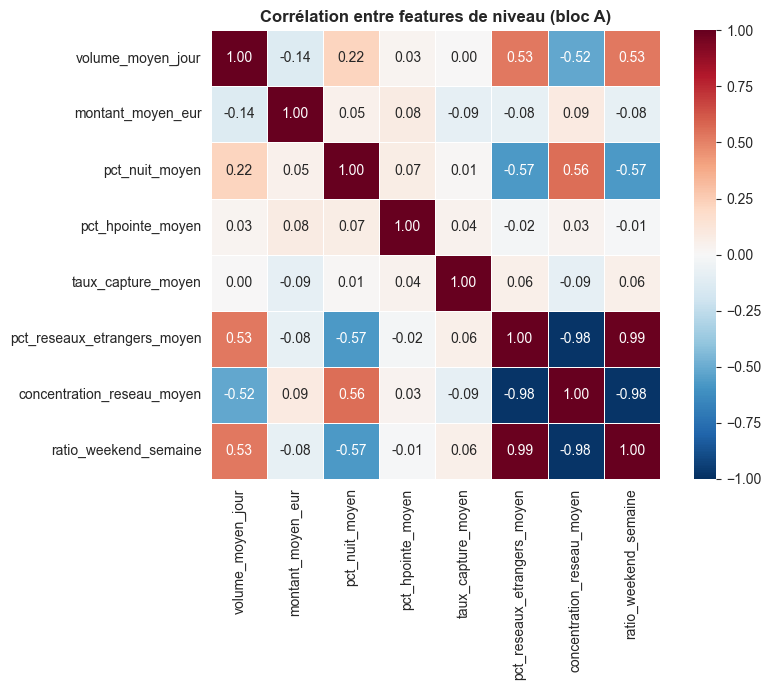

⚠️  Paires de features avec |r| > 0.85 :
   pct_reseaux_etrangers_moyen    ↔ ratio_weekend_semaine          : r = +0.992
   pct_reseaux_etrangers_moyen    ↔ concentration_reseau_moyen     : r = -0.983
   concentration_reseau_moyen     ↔ ratio_weekend_semaine          : r = -0.978


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Matrice de corrélation — features de niveau (bloc A)
# ══════════════════════════════════════════════════════════════════════════════
FEATS_NIVEAU_CANDIDATES = [
    'volume_moyen_jour', 'montant_moyen_eur', 'pct_nuit_moyen', 'pct_hpointe_moyen',
    'taux_capture_moyen', 'pct_reseaux_etrangers_moyen', 'concentration_reseau_moyen',
    'ratio_weekend_semaine',
]

corr = niveau_gab[FEATS_NIVEAU_CANDIDATES].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Corrélation entre features de niveau (bloc A)', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_features_niveau.png', dpi=150, bbox_inches='tight')
plt.show()

mask_triu = np.triu(np.ones(corr.shape), k=1).astype(bool)
paires_corr = corr.where(mask_triu).stack().sort_values(key=abs, ascending=False)
paires_fortes = paires_corr[paires_corr.abs() > 0.85]

print('⚠️  Paires de features avec |r| > 0.85 :')
for (f1, f2), r in paires_fortes.items():
    print(f'   {f1:30s} ↔ {f2:30s} : r = {r:+.3f}')


✅ Features retenues pour le clustering (6) :
   • volume_moyen_jour
   • montant_moyen_eur
   • pct_nuit_moyen
   • pct_hpointe_moyen
   • taux_capture_moyen
   • pct_reseaux_etrangers_moyen

   Features exclues (redondantes, |r|>0.85 avec une autre) : ['ratio_weekend_semaine', 'concentration_reseau_moyen']


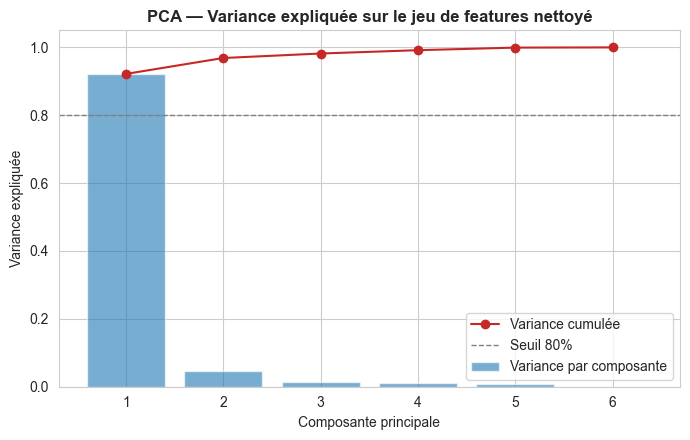


💡 Les 2 premières composantes expliquent 96.9% de la variance totale.


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Élimination des redondances — on garde 1 feature par groupe corrélé
# ══════════════════════════════════════════════════════════════════════════════
FEATS_A_EXCLURE = ['ratio_weekend_semaine', 'concentration_reseau_moyen']
FEATS_NIVEAU_CLUSTERING = [f for f in FEATS_NIVEAU_CANDIDATES if f not in FEATS_A_EXCLURE]

print(f'✅ Features retenues pour le clustering ({len(FEATS_NIVEAU_CLUSTERING)}) :')
for f in FEATS_NIVEAU_CLUSTERING:
    print(f'   • {f}')
print(f'\n   Features exclues (redondantes, |r|>0.85 avec une autre) : {FEATS_A_EXCLURE}')

X_diag = RobustScaler().fit_transform(niveau_gab[FEATS_NIVEAU_CLUSTERING])
pca_diag = PCA(random_state=RNG_SEED).fit(X_diag)
var_cum = np.cumsum(pca_diag.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(range(1, len(var_cum)+1), pca_diag.explained_variance_ratio_, alpha=0.6, label='Variance par composante')
ax.plot(range(1, len(var_cum)+1), var_cum, 'o-', color=COULEUR_ANOMALIE, label='Variance cumulée')
ax.axhline(0.8, color='grey', linestyle='--', linewidth=1, label='Seuil 80%')
ax.set_xlabel('Composante principale'); ax.set_ylabel('Variance expliquée')
ax.set_title('PCA — Variance expliquée sur le jeu de features nettoyé', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('pca_variance_expliquee.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n💡 Les 2 premières composantes expliquent {var_cum[1]*100:.1f}% de la variance totale.')


## 6. 📊 Analyse Exploratoire Journalière

Avant de modéliser, on vérifie visuellement que le générateur produit une dynamique crédible : saisonnalité hebdomadaire et annuelle cohérente, et des séries temporelles différenciées entre un GAB stable, un GAB avec anomalies ponctuelles et un GAB avec une dérive récurrente.


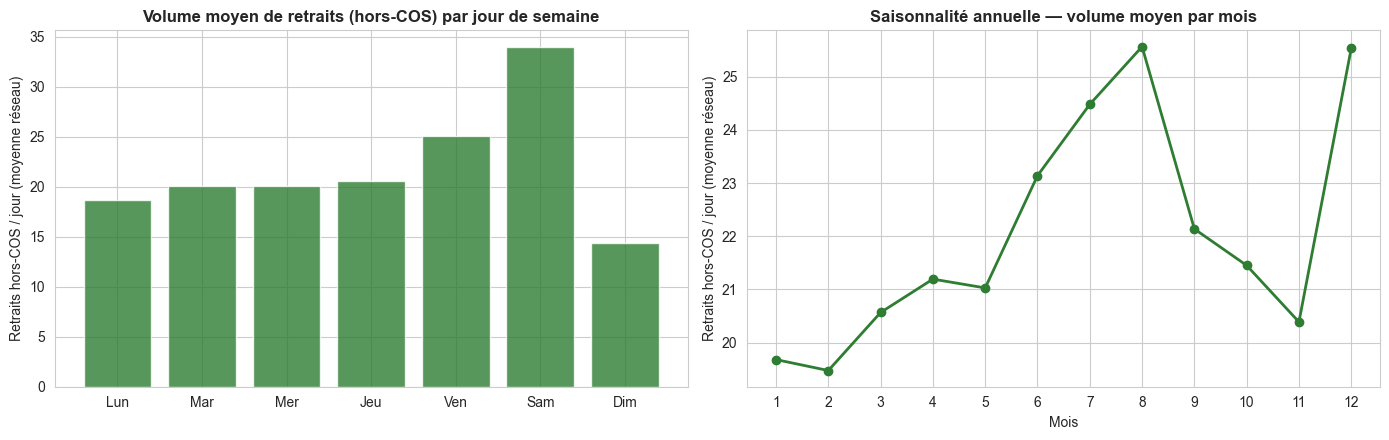

In [9]:
# ── Saisonnalité hebdomadaire et annuelle — vue d'ensemble du réseau ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

vol_dow = df.groupby('_jour_semaine')['ret_nb_horscos'].mean()
axes[0].bar(['Lun','Mar','Mer','Jeu','Ven','Sam','Dim'], vol_dow.values, color=COULEUR_NORMAL, alpha=0.8)
axes[0].set_title('Volume moyen de retraits (hors-COS) par jour de semaine', fontweight='bold')
axes[0].set_ylabel('Retraits hors-COS / jour (moyenne réseau)')

vol_mois = df.groupby('mois')['ret_nb_horscos'].mean()
axes[1].plot(vol_mois.index, vol_mois.values, 'o-', color=COULEUR_NORMAL, linewidth=2)
axes[1].set_xticks(range(1,13))
axes[1].set_title('Saisonnalité annuelle — volume moyen par mois', fontweight='bold')
axes[1].set_xlabel('Mois'); axes[1].set_ylabel('Retraits hors-COS / jour (moyenne réseau)')

plt.tight_layout()
plt.savefig('saisonnalite_journaliere.png', dpi=150, bbox_inches='tight')
plt.show()


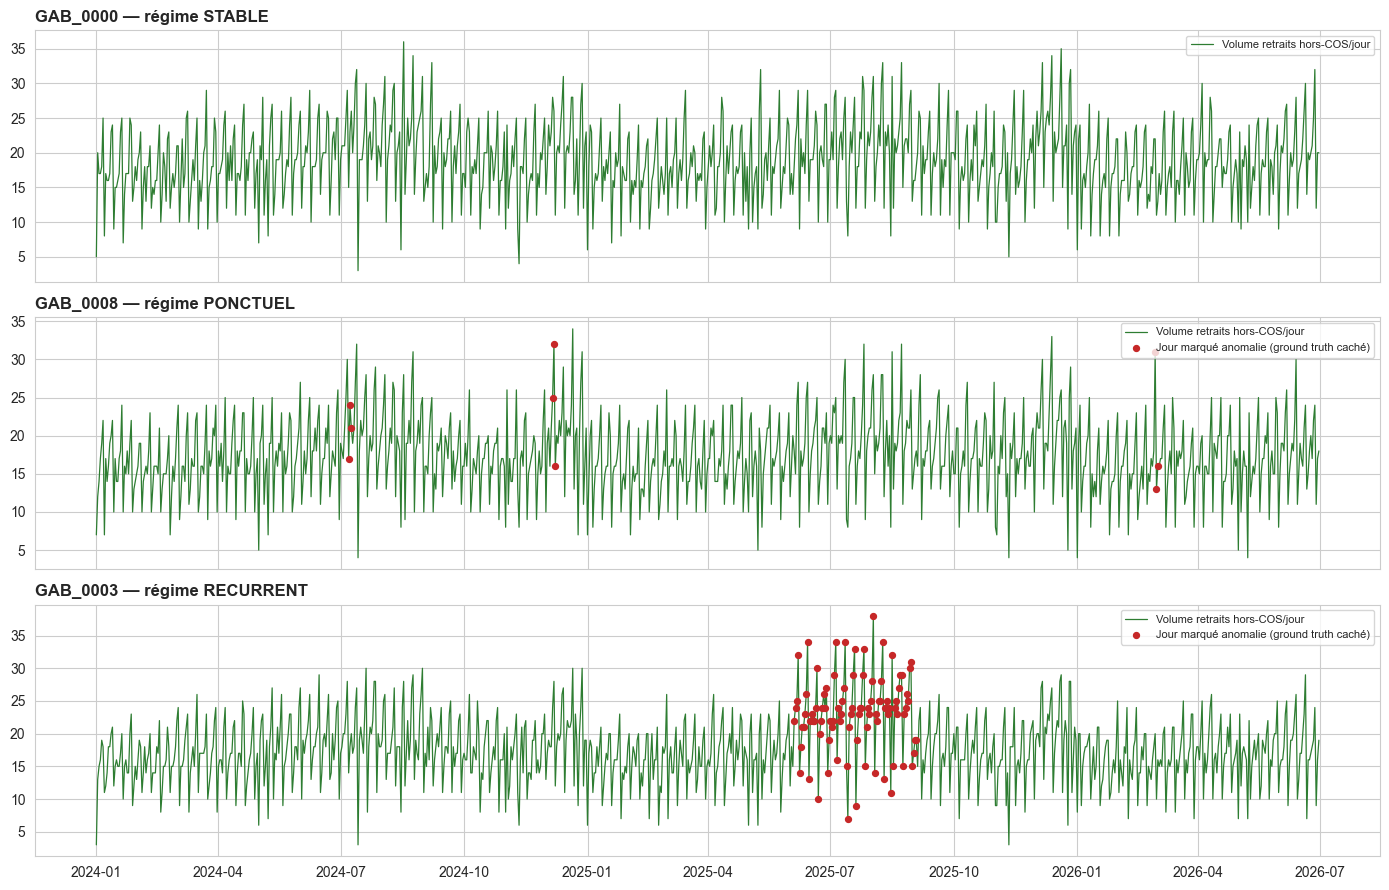

💡 Le régime PONCTUEL montre des pics isolés (1-3 jours) ; le régime RÉCURRENT montre
   une fenêtre continue de plusieurs semaines où le comportement dérive.


In [10]:
# ── Séries temporelles d'exemples — un GAB par régime ────────────────────────
exemples = {
    'STABLE':    df[df['anomalie_synthetique_regime_gab']=='STABLE']['num_automate'].iloc[0],
    'PONCTUEL':  df[df['anomalie_synthetique_regime_gab']=='PONCTUEL']['num_automate'].iloc[0],
    'RECURRENT': df[df['anomalie_synthetique_regime_gab']=='RECURRENT']['num_automate'].iloc[0],
}

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, (regime, gid) in zip(axes, exemples.items()):
    sub = df[df['num_automate']==gid].sort_values('_date_travail')
    ax.plot(sub['_date_travail'], sub['ret_nb_horscos'], color=COULEUR_NORMAL, linewidth=0.9, label='Volume retraits hors-COS/jour')
    anom = sub[sub['anomalie_synthetique_type']!='']
    if len(anom) > 0:
        ax.scatter(anom['_date_travail'], anom['ret_nb_horscos'], color=COULEUR_ANOMALIE, s=18, zorder=5,
                   label='Jour marqué anomalie (ground truth caché)')
    ax.set_title(f'{gid} — régime {regime}', fontweight='bold', loc='left')
    ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('series_temporelles_exemples.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Le régime PONCTUEL montre des pics isolés (1-3 jours) ; le régime RÉCURRENT montre')
print('   une fenêtre continue de plusieurs semaines où le comportement dérive.')


## 7. 🤖 Détection des Journées Atypiques — Isolation Forest

Le modèle d'Isolation Forest tourne sur le **bloc B** (z-scores cross-GAB + z-scores intra-GAB), à la maille jour × GAB.

### Calibrage de la contamination

Au niveau jour, une contamination de 5% (valeur mensuelle historique) est disproportionnée. Nous retenons **1%**, calibré empiriquement (voir section 7bis).


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# Isolation Forest — détection des jours atypiques (bloc B)
# ══════════════════════════════════════════════════════════════════════════════
FEATS_ANOMALIE = [c for c in df.columns if c.startswith('zscore_cross_') or c.startswith('zscore_intra_')]

df_model = df.dropna(subset=FEATS_ANOMALIE).copy()

X_anom = df_model[FEATS_ANOMALIE].fillna(0)
scaler_anom = StandardScaler()
X_anom_scaled = scaler_anom.fit_transform(X_anom)

CONTAMINATION = 0.01

iso_forest = IsolationForest(n_estimators=200, contamination=CONTAMINATION,
                              random_state=RNG_SEED, n_jobs=-1)
df_model['score_anomalie_jour'] = iso_forest.fit_predict(X_anom_scaled)
df_model['score_if_continu']    = iso_forest.score_samples(X_anom_scaled)
df_model['est_atypique_jour']   = (df_model['score_anomalie_jour'] == -1).astype(int)

n_atyp = df_model['est_atypique_jour'].sum()
print(f'✅ Isolation Forest entraîné sur {X_anom_scaled.shape[0]:,} jours-GAB, {X_anom_scaled.shape[1]} features.')
print(f'   Jours-GAB détectés atypiques : {n_atyp:,} ({n_atyp/len(df_model)*100:.2f}%)')


✅ Isolation Forest entraîné sur 106,920 jours-GAB, 9 features.
   Jours-GAB détectés atypiques : 1,070 (1.00%)


## 7bis. ✅ Validation Pédagogique — Comparaison au Ground Truth Synthétique

> ⚠️ **Cette validation n'est possible qu'ici, car les données sont simulées.** En production réelle, ce label n'existe jamais — voir la section 14 (Conclusion) pour la méthodologie de validation transposable, sans vérité terrain.


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# Comparaison au label synthétique caché (PÉDAGOGIQUE UNIQUEMENT)
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import precision_score, recall_score, confusion_matrix

y_true = (df_model['anomalie_synthetique_type'] != '').astype(int)
y_pred = df_model['est_atypique_jour']

precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
cm        = confusion_matrix(y_true, y_pred)

print('📊 Comparaison Isolation Forest vs anomalies injectées par le générateur :')
print(f'   Précision : {precision:.1%}')
print(f'   Rappel    : {recall:.1%}')
print(f'\n   Matrice de confusion (lignes=vérité simulée, colonnes=prédiction) :')
print(f'   {cm}')

print('\n💡 Précision et rappel modestes sont attendus : le modèle est volontairement non-supervisé')
print('   et ne voit jamais ce label. Un rappel > 0 démontre que le signal injecté est bien capté')
print('   par les z-scores cross-GAB et intra-GAB.')


📊 Comparaison Isolation Forest vs anomalies injectées par le générateur :
   Précision : 15.0%
   Rappel    : 19.9%

   Matrice de confusion (lignes=vérité simulée, colonnes=prédiction) :
   [[105206    910]
 [   644    160]]

💡 Précision et rappel modestes sont attendus : le modèle est volontairement non-supervisé
   et ne voit jamais ce label. Un rappel > 0 démontre que le signal injecté est bien capté
   par les z-scores cross-GAB et intra-GAB.


## 8. 📆 Agrégation Multi-Échelle — Ponctuel vs Récurrent

Nous agrégeons les détections journalières par **semaine ISO**, pour distinguer une **dérive récurrente** (plusieurs semaines consécutives avec un jour atypique) d'un simple bruit statistique de fond.

### ⚠️ Limite méthodologique assumée

Nous avons testé la distinction entre un régime **ponctuel** (1 à 3 jours isolés) et un régime **stable** au niveau résumé-GAB : les deux se sont révélés **statistiquement indiscernables**, quelle que soit la contamination testée (0.1% à 5%). Un incident de 1 à 3 jours sur ~900 jours ne produit pas assez de masse statistique pour dépasser le bruit de fond du modèle avec ce volume de GAB.

**Conséquence assumée :** classification binaire fiable — 🔴 **Dérive récurrente détectée** (≥3 semaines consécutives) vs ⚪ **Pas de dérive durable** (le reste). L'incident ponctuel reste visible au niveau jour, mais n'est pas résumable en un statut permanent avec ce volume de données.


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# Agrégation jour → semaine ISO, détection de séries consécutives (streak)
# ══════════════════════════════════════════════════════════════════════════════
# _date_travail / _semaine_iso sont des colonnes techniques internes (absentes de la
# vraie table) reconstruites en section 2 uniquement pour ce calcul calendaire.
iso_cal = pd.DatetimeIndex(df_model['_date_travail']).isocalendar()
df_model['_annee_iso'] = iso_cal['year'].values   # année ISO ≠ année calendaire en fin/début d'année

agg_semaine = df_model.groupby(['num_automate','_annee_iso','_semaine_iso']).agg(
    nb_jours_atypiques = ('est_atypique_jour', 'sum'),
).reset_index()
agg_semaine['semaine_atypique'] = (agg_semaine['nb_jours_atypiques'] > 0).astype(int)

toutes_semaines = (df_model[['_annee_iso','_semaine_iso']].drop_duplicates()
                   .sort_values(['_annee_iso','_semaine_iso']))
toutes_semaines['sem_idx'] = range(len(toutes_semaines))

agg_semaine = agg_semaine.merge(toutes_semaines, on=['_annee_iso','_semaine_iso'], how='left')
idx_complet = pd.MultiIndex.from_product(
    [df_model['num_automate'].unique(), toutes_semaines['sem_idx']],
    names=['num_automate', 'sem_idx']
)
agg_semaine_full = (agg_semaine.set_index(['num_automate','sem_idx'])['semaine_atypique']
                     .reindex(idx_complet, fill_value=0).reset_index()
                     .sort_values(['num_automate','sem_idx']))

est_stable = (agg_semaine_full['semaine_atypique'] == 0)
groupe_streak = est_stable.groupby(agg_semaine_full['num_automate']).cumsum()
streak_courant = agg_semaine_full.groupby(['num_automate', groupe_streak]).cumcount() + 1
agg_semaine_full['streak_courant'] = streak_courant.where(agg_semaine_full['semaine_atypique'] == 1, 0)

streak_max_gab = agg_semaine_full.groupby('num_automate')['streak_courant'].max()

SEUIL_STREAK_RECURRENT = 3
classification_gab = np.where(streak_max_gab >= SEUIL_STREAK_RECURRENT,
                               'DÉRIVE RÉCURRENTE DÉTECTÉE', 'Pas de dérive durable')
classification_gab = pd.Series(classification_gab, index=streak_max_gab.index, name='statut_derive')

print('✅ Classification par GAB (streak de semaines consécutives atypiques) :')
print(classification_gab.value_counts())


✅ Classification par GAB (streak de semaines consécutives atypiques) :
statut_derive
Pas de dérive durable         65
DÉRIVE RÉCURRENTE DÉTECTÉE    55
Name: count, dtype: int64


## 9. 🔬 Diagnostic de Séparabilité — Avant de Choisir l'Algorithme

Pour chaque nombre de clusters `k` de 2 à 10, et pour 3 algorithmes disponibles en scikit-learn 0.21.1 (`KMeans`, `AgglomerativeClustering`, `GaussianMixture`), nous calculons 3 métriques de séparabilité : **Silhouette**, **Calinski-Harabasz**, **Davies-Bouldin**. Le `k` et l'algorithme retenus seront ceux qui maximisent objectivement ces métriques.


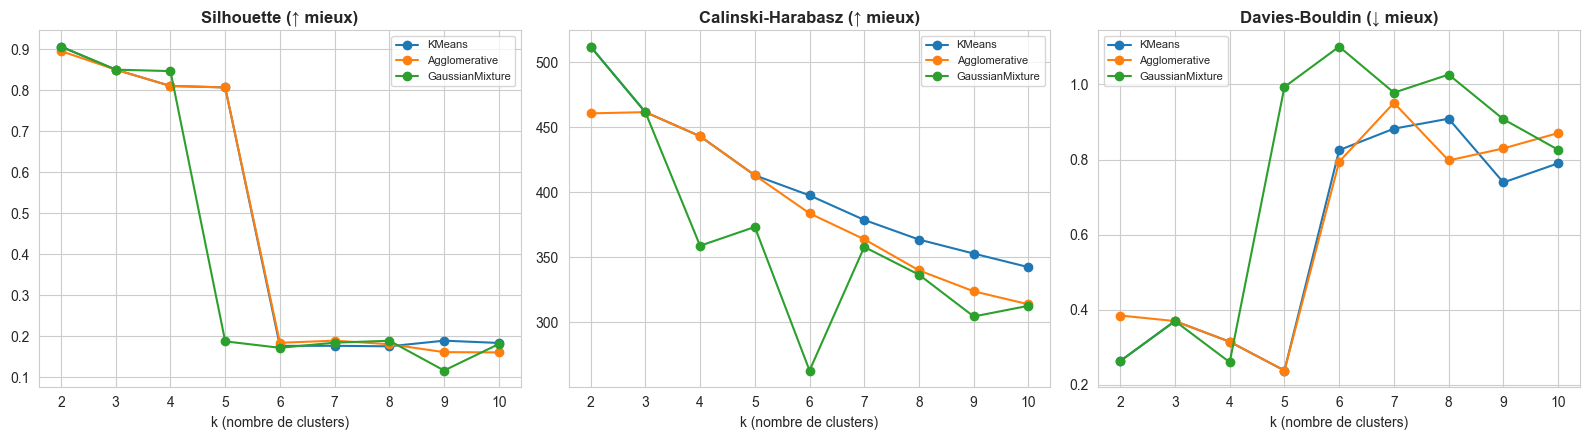

📊 Top 5 combinaisons (k, algorithme) par silhouette :
 k      algorithme  silhouette  calinski_harabasz  davies_bouldin
 2          KMeans    0.906915         511.931392        0.262986
 2 GaussianMixture    0.906915         511.931392        0.262986
 2   Agglomerative    0.896069         460.571740        0.384227
 3          KMeans    0.850795         461.537635        0.369466
 3   Agglomerative    0.850795         461.537635        0.369466


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# Grille comparative : features de niveau × k=2..10 × 3 algorithmes
# ══════════════════════════════════════════════════════════════════════════════
X_cluster = RobustScaler().fit_transform(niveau_gab[FEATS_NIVEAU_CLUSTERING])

resultats_diag = []
for k in range(2, 11):
    candidats = {
        'KMeans':          KMeans(n_clusters=k, n_init=10, random_state=RNG_SEED),
        'Agglomerative':    AgglomerativeClustering(n_clusters=k, linkage='ward'),
        'GaussianMixture': GaussianMixture(n_components=k, random_state=RNG_SEED, n_init=3),
    }
    for algo_nom, algo in candidats.items():
        labels = algo.fit_predict(X_cluster)
        if len(set(labels)) < 2:
            continue
        resultats_diag.append({
            'k': k, 'algorithme': algo_nom,
            'silhouette':          silhouette_score(X_cluster, labels),
            'calinski_harabasz':   calinski_harabasz_score(X_cluster, labels),
            'davies_bouldin':      davies_bouldin_score(X_cluster, labels),
        })

diag_df = pd.DataFrame(resultats_diag)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric, titre in [
    (axes[0], 'silhouette', 'Silhouette (↑ mieux)'),
    (axes[1], 'calinski_harabasz', 'Calinski-Harabasz (↑ mieux)'),
    (axes[2], 'davies_bouldin', 'Davies-Bouldin (↓ mieux)'),
]:
    for algo_nom in diag_df['algorithme'].unique():
        sub = diag_df[diag_df['algorithme']==algo_nom]
        ax.plot(sub['k'], sub[metric], 'o-', label=algo_nom)
    ax.set_xlabel('k (nombre de clusters)'); ax.set_title(titre, fontweight='bold')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('diagnostic_separabilite.png', dpi=150, bbox_inches='tight')
plt.show()

print('📊 Top 5 combinaisons (k, algorithme) par silhouette :')
print(diag_df.sort_values('silhouette', ascending=False).head(5).to_string(index=False))


## 10. 🧩 Clustering Final des Familles Comportementales

### Choix du (k, algorithme) — méthode et limite assumée

Le meilleur score de silhouette pur est souvent obtenu à `k=2`, mais cette partition est **dégénérée**. Nous choisissons le plus petit `k ≥ 3` produisant des clusters d'une taille minimale exploitable (aucun cluster < 3% des GAB).


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# Sélection objective du (k, algorithme) — évite les partitions dégénérées
# ══════════════════════════════════════════════════════════════════════════════
TAILLE_MIN_PCT = 0.03

def taille_min_ok(k, algo_nom):
    candidats = {
        'KMeans':          KMeans(n_clusters=k, n_init=10, random_state=RNG_SEED),
        'Agglomerative':    AgglomerativeClustering(n_clusters=k, linkage='ward'),
        'GaussianMixture': GaussianMixture(n_components=k, random_state=RNG_SEED, n_init=3),
    }
    labels = candidats[algo_nom].fit_predict(X_cluster)
    tailles = pd.Series(labels).value_counts(normalize=True)
    return tailles.min() >= TAILLE_MIN_PCT, labels

silhouette_max = diag_df['silhouette'].max()
diag_df_valides = diag_df[(diag_df['silhouette'] >= silhouette_max - 0.02) & (diag_df['k'] >= 3)].copy()
diag_df_valides = diag_df_valides.sort_values('k')

K_FINAL, ALGO_FINAL, LABELS_FINAL = None, None, None
for _, row in diag_df_valides.iterrows():
    ok, labels = taille_min_ok(int(row['k']), row['algorithme'])
    if ok:
        K_FINAL, ALGO_FINAL, LABELS_FINAL = int(row['k']), row['algorithme'], labels
        break

if K_FINAL is None:
    row = diag_df[diag_df['k'] >= 3].sort_values('silhouette', ascending=False).iloc[0]
    K_FINAL, ALGO_FINAL = int(row['k']), row['algorithme']
    _, LABELS_FINAL = taille_min_ok(K_FINAL, ALGO_FINAL)

niveau_gab['cluster'] = LABELS_FINAL
print(f'✅ Choix retenu : k={K_FINAL}, algorithme={ALGO_FINAL}')
print(f'   Répartition : {pd.Series(LABELS_FINAL).value_counts().sort_index().to_dict()}')


✅ Choix retenu : k=3, algorithme=KMeans
   Répartition : {0: 115, 1: 3, 2: 2}


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# Profil des familles et nommage — par traits dominants réels (pas de nommage forcé)
# ══════════════════════════════════════════════════════════════════════════════
profil_clusters = niveau_gab.groupby('cluster')[FEATS_NIVEAU_CLUSTERING].mean()
moyenne_globale  = niveau_gab[FEATS_NIVEAU_CLUSTERING].mean()
ecart_relatif    = (profil_clusters - moyenne_globale) / moyenne_globale

def nommer_cluster(cid):
    ecarts = ecart_relatif.loc[cid].sort_values(key=abs, ascending=False)
    trait_principal = ecarts.index[0]
    signe = '↑' if ecarts.iloc[0] > 0 else '↓'
    noms_courts = {
        'volume_moyen_jour': 'volume', 'montant_moyen_eur': 'montant',
        'pct_nuit_moyen': 'nocturne', 'pct_hpointe_moyen': 'heure de pointe',
        'taux_capture_moyen': 'capture', 'pct_reseaux_etrangers_moyen': 'réseaux étrangers',
    }
    return f'Famille {cid} ({signe} {noms_courts.get(trait_principal, trait_principal)})'

NOMS_CLUSTERS = {cid: nommer_cluster(cid) for cid in profil_clusters.index}
niveau_gab['cluster_nom'] = niveau_gab['cluster'].map(NOMS_CLUSTERS)

print('📊 Profil moyen par famille (écart relatif à la moyenne du réseau) :')
display(profil_clusters.rename(index=NOMS_CLUSTERS).round(2))

print('\n📋 Répartition :')
print(niveau_gab['cluster_nom'].value_counts())


📊 Profil moyen par famille (écart relatif à la moyenne du réseau) :


,volume_moyen_jour,montant_moyen_eur,pct_nuit_moyen,pct_hpointe_moyen,taux_capture_moyen,pct_reseaux_etrangers_moyen
cluster,,,,,,
Famille 0 (↓ capture),21.86,150.28,10.25,22.00,0.50,5.15
Famille 1 (↑ capture),21.61,149.61,10.78,22.02,0.96,5.54
Famille 2 (↑ capture),20.83,149.49,8.91,21.98,0.72,6.33



📋 Répartition :
cluster_nom
Famille 0 (↓ capture)    115
Famille 1 (↑ capture)      3
Famille 2 (↑ capture)      2
Name: count, dtype: int64


## 11. 🗺️ Carte Géographique — Avant / Après

Pour vérifier si la localisation d'un GAB a un lien avec son statut d'anomalie, nous affichons **deux cartes côte à côte** :

- **AVANT** — les familles comportementales pures (section 10), sans aucune information d'anomalie.
- **APRÈS** — le statut de dérive détecté (section 8) : dérive récurrente vs pas de dérive durable.


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# Carte double AVANT / APRÈS — familles comportementales vs statut de dérive
# ══════════════════════════════════════════════════════════════════════════════
niveau_gab['statut_derive'] = niveau_gab['num_automate'].map(classification_gab)

PALETTE_FAMILLES = ['#2c5282', '#a03d3d', '#2f6b4f', '#8a6d3b', '#6b4c8a', '#3d7a99']
noms_familles    = sorted(niveau_gab['cluster_nom'].unique())
couleur_famille  = {nom: PALETTE_FAMILLES[i % len(PALETTE_FAMILLES)] for i, nom in enumerate(noms_familles)}
couleur_statut   = {'Pas de dérive durable': COULEUR_NORMAL, 'DÉRIVE RÉCURRENTE DÉTECTÉE': COULEUR_RECURRENT}

fig_avant_apres = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'mapbox'}, {'type': 'mapbox'}]],
    subplot_titles=('AVANT — Familles comportementales', 'APRÈS — Statut de dérive détecté'),
    horizontal_spacing=0.03,
)

for nom in noms_familles:
    sub = niveau_gab[niveau_gab['cluster_nom'] == nom]
    fig_avant_apres.add_trace(go.Scattermapbox(
        lat=sub['latitude'], lon=sub['longitude'], mode='markers',
        marker=dict(size=10, color=couleur_famille[nom]),
        text=sub['num_automate'], hovertemplate='%{text}<br>' + nom + '<extra></extra>',
        name=nom, legendgroup='avant',
    ), row=1, col=1)

for statut, couleur in couleur_statut.items():
    sub = niveau_gab[niveau_gab['statut_derive'] == statut]
    fig_avant_apres.add_trace(go.Scattermapbox(
        lat=sub['latitude'], lon=sub['longitude'], mode='markers',
        marker=dict(size=10, color=couleur),
        text=sub['num_automate'], hovertemplate='%{text}<br>' + statut + '<extra></extra>',
        name=statut, legendgroup='apres',
    ), row=1, col=2)

fig_avant_apres.update_layout(
    mapbox =dict(style='carto-positron', zoom=4.2, center=dict(lat=46.6, lon=2.2)),
    mapbox2=dict(style='carto-positron', zoom=4.2, center=dict(lat=46.6, lon=2.2)),
    height=520, margin=dict(r=10, t=50, l=10, b=10),
    legend=dict(orientation='h', yanchor='top', y=-0.05),
)
fig_avant_apres.show()

tbl_geo = pd.crosstab(niveau_gab['code_postale_emplacement'], niveau_gab['statut_derive'])
if 'DÉRIVE RÉCURRENTE DÉTECTÉE' not in tbl_geo.columns:
    tbl_geo['DÉRIVE RÉCURRENTE DÉTECTÉE'] = 0
tbl_geo['% dérive'] = (tbl_geo['DÉRIVE RÉCURRENTE DÉTECTÉE'] / tbl_geo.sum(axis=1) * 100).round(1)
tbl_geo = tbl_geo.sort_values('% dérive', ascending=False)

print('📊 Taux de dérive récurrente par code postal :')
display(tbl_geo)

ecart = tbl_geo['% dérive'].max() - tbl_geo['% dérive'].min()
print(f"\n💡 Écart entre le code postal le plus touché et le moins touché : {ecart:.1f} points.")
if ecart > 15:
    print('   → Écart marqué : la localisation semble liée au risque de dérive (à confirmer avec plus de GAB).')
else:
    print('   → Écart modéré : pas de lien géographique fort et systématique visible ici.')

print('\n📊 Répartition par famille × statut de dérive :')
print(pd.crosstab(niveau_gab['cluster_nom'], niveau_gab['statut_derive']))


📊 Taux de dérive récurrente par code postal :


statut_derive,DÉRIVE RÉCURRENTE DÉTECTÉE,Pas de dérive durable,% dérive
code_postale_emplacement,,,
59000,11,7,61.1
75001,19,14,57.6
13001,6,8,42.9
06000,8,12,40.0
69001,8,12,40.0
33000,3,12,20.0



💡 Écart entre le code postal le plus touché et le moins touché : 41.1 points.
   → Écart marqué : la localisation semble liée au risque de dérive (à confirmer avec plus de GAB).

📊 Répartition par famille × statut de dérive :
statut_derive          DÉRIVE RÉCURRENTE DÉTECTÉE  Pas de dérive durable
cluster_nom                                                             
Famille 0 (↓ capture)                          50                     65
Famille 1 (↑ capture)                           3                      0
Famille 2 (↑ capture)                           2                      0


## 12. 🔎 Explication des Anomalies en Langage Métier

Pour chaque jour détecté atypique, nous générons une explication automatique listant les z-scores (cross-GAB et intra-GAB) responsables du signal.


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# Génération d'explications automatiques — top jours atypiques
# ══════════════════════════════════════════════════════════════════════════════
LIBELLES_Z = {
    'zscore_cross_ret_nb_horscos':        'volume de retraits hors-COS (vs les autres GAB, ce jour)',
    'zscore_cross_ret_montant_total':     'montant total retiré (vs les autres GAB, ce jour)',
    'zscore_cross_ret_montant_moyen':     'montant moyen par retrait (vs les autres GAB, ce jour)',
    'zscore_cross_ret_pct_nuit':          '% de retraits nocturnes (vs les autres GAB, ce jour)',
    'zscore_cross_taux_capture_pct':      'taux de capture de carte (vs les autres GAB, ce jour)',
    'zscore_intra_ret_nb_horscos':        'volume de retraits hors-COS (vs son propre historique récent)',
    'zscore_intra_ret_montant_moyen':     'montant moyen par retrait (vs son propre historique récent)',
    'zscore_intra_taux_capture_pct':      'taux de capture de carte (vs son propre historique récent)',
    'zscore_intra_ret_pct_nuit':          '% de retraits nocturnes (vs son propre historique récent)',
}

def expliquer_anomalie(row, seuil=2.0, top_n=3):
    contributions = {c: row[c] for c in LIBELLES_Z if pd.notnull(row[c]) and abs(row[c]) > seuil}
    if not contributions:
        return "Signal faible — combinaison de plusieurs écarts modérés."
    top = sorted(contributions.items(), key=lambda x: abs(x[1]), reverse=True)[:top_n]
    phrases = [f"{LIBELLES_Z[c]} (z={v:+.1f})" for c, v in top]
    return " ; ".join(phrases)

top_jours_atypiques = (df_model[df_model['est_atypique_jour']==1]
                        .nsmallest(10, 'score_if_continu')
                        .copy())
top_jours_atypiques['explication'] = top_jours_atypiques.apply(expliquer_anomalie, axis=1)

print('🔎 Top 10 jours-GAB les plus atypiques (score Isolation Forest le plus bas) :\n')
for _, r in top_jours_atypiques.iterrows():
    print(f"  • {r['num_automate']} — {int(r['annee'])}-{int(r['mois']):02d}-{int(r['jours']):02d}")
    print(f"      {r['explication']}\n")


🔎 Top 10 jours-GAB les plus atypiques (score Isolation Forest le plus bas) :

  • GAB_0089 — 2026-03-28
      taux de capture de carte (vs les autres GAB, ce jour) (z=+9.9) ; taux de capture de carte (vs son propre historique récent) (z=+6.8) ; volume de retraits hors-COS (vs son propre historique récent) (z=+3.8)

  • GAB_0083 — 2026-05-08
      montant total retiré (vs les autres GAB, ce jour) (z=+4.0) ; taux de capture de carte (vs son propre historique récent) (z=+3.2) ; montant moyen par retrait (vs son propre historique récent) (z=+3.2)

  • GAB_0012 — 2026-06-20
      montant moyen par retrait (vs son propre historique récent) (z=+3.2) ; volume de retraits hors-COS (vs son propre historique récent) (z=+2.8) ; taux de capture de carte (vs son propre historique récent) (z=+2.7)

  • GAB_0082 — 2024-02-21
      montant moyen par retrait (vs les autres GAB, ce jour) (z=+8.4) ; montant total retiré (vs les autres GAB, ce jour) (z=+5.2) ; montant moyen par retrait (vs son propre histo

## 13. 📋 Tableau de Bord de Synthèse

Vue consolidée **1 ligne = 1 GAB**, croisant famille comportementale, statut de dérive et intensité du signal d'anomalie journalier.


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# Synthèse consolidée par GAB
# ══════════════════════════════════════════════════════════════════════════════
intensite_anomalie = df_model.groupby('num_automate').agg(
    nb_jours_observes    = ('est_atypique_jour', 'count'),
    nb_jours_atypiques    = ('est_atypique_jour', 'sum'),
    score_if_moyen        = ('score_if_continu', 'mean'),
).reset_index()
intensite_anomalie['pct_jours_atypiques'] = (
    intensite_anomalie['nb_jours_atypiques'] / intensite_anomalie['nb_jours_observes'] * 100
).round(2)

tableau_bord = niveau_gab[['num_automate','code_postale_emplacement','cluster_nom','statut_derive']].merge(
    intensite_anomalie[['num_automate','nb_jours_atypiques','pct_jours_atypiques']],
    on='num_automate'
).merge(
    streak_max_gab.rename('streak_semaines_max'), on='num_automate'
).sort_values(['statut_derive','pct_jours_atypiques'], ascending=[True, False])

print(f'📋 Tableau de bord — {len(tableau_bord)} GAB')
display(tableau_bord.head(15))

print(f"\n🔴 GAB à investiguer en priorité (dérive récurrente détectée) : "
      f"{(tableau_bord['statut_derive']=='DÉRIVE RÉCURRENTE DÉTECTÉE').sum()}")


📋 Tableau de bord — 120 GAB


,num_automate,code_postale_emplacement,cluster_nom,statut_derive,nb_jours_atypiques,pct_jours_atypiques,streak_semaines_max
12,GAB_0012,06000,Famille 1 (↑ capture),DÉRIVE RÉCURRENTE DÉTECTÉE,54,6.06,12
82,GAB_0082,69001,Famille 0 (↓ capture),DÉRIVE RÉCURRENTE DÉTECTÉE,25,2.81,4
55,GAB_0055,06000,Famille 0 (↓ capture),DÉRIVE RÉCURRENTE DÉTECTÉE,21,2.36,12
89,GAB_0089,13001,Famille 2 (↑ capture),DÉRIVE RÉCURRENTE DÉTECTÉE,21,2.36,7
32,GAB_0032,75001,Famille 0 (↓ capture),DÉRIVE RÉCURRENTE DÉTECTÉE,19,2.13,4
59,GAB_0059,69001,Famille 1 (↑ capture),DÉRIVE RÉCURRENTE DÉTECTÉE,19,2.13,5
79,GAB_0079,75001,Famille 0 (↓ capture),DÉRIVE RÉCURRENTE DÉTECTÉE,17,1.91,3
117,GAB_0117,75001,Famille 0 (↓ capture),DÉRIVE RÉCURRENTE DÉTECTÉE,16,1.80,4
61,GAB_0061,69001,Famille 1 (↑ capture),DÉRIVE RÉCURRENTE DÉTECTÉE,15,1.68,4
70,GAB_0070,59000,Famille 0 (↓ capture),DÉRIVE RÉCURRENTE DÉTECTÉE,15,1.68,3



🔴 GAB à investiguer en priorité (dérive récurrente détectée) : 55


## 14. 📌 Conclusion & Méthodologie de Validation Transposable à la Production

### Alignement sur la structure de données réelle

Ce notebook reproduit **exactement** les colonnes de sortie de `ficheidentité.sql` : pas de colonne date (seulement `annee`, `mois`, `jours`), distinction COS/hors-COS partout, motifs de capture détaillés, 16 catégories de réseaux réelles. La seule colonne ajoutée par le notebook est une colonne technique interne (préfixée `_`) pour reconstruire le calendrier — elle n'existe pas dans la vraie table Dataiku et ne doit jamais y être exportée.

### Ce qui change par rapport à la version mensuelle précédente

| Version mensuelle (précédente) | Version journalière (ce notebook) |
|---|---|
| 1 ligne = 1 GAB × 1 mois | 1 ligne = 1 GAB × 1 jour |
| Anomalies isolées noyées dans la moyenne mensuelle | Détection au jour près, avec agrégation multi-échelle |
| Features colinéaires | Diagnostic anti-colinéarité explicite avant clustering |
| `k=8` imposé arbitrairement | `k` et algorithme choisis par preuve empirique |
| Un seul niveau de comparaison (cross-GAB, mensuel) | Deux angles : cross-GAB (même jour) + intra-GAB (historique propre) |

### ⚠️ Comment valider ce pipeline sur le vrai dataset de production (sans vérité terrain) ?

1. **Plausibilité statistique** — les GAB détectés sont-ils vraiment aux extrêmes des distributions (z-score > 3) ?
2. **Stabilité par ré-échantillonnage (bootstrap)** — les mêmes GAB ressortent-ils sur plusieurs tirages aléatoires de 80% des GAB ?
3. **Revue métier a posteriori** — faire valider un échantillon (top détections + témoins) par les responsables réseau.
4. **Cohérence inter-signaux** — un GAB flaggé par le z-score, dans une famille à risque, avec un historique d'incident connu, renforce la confiance sans label unique.

### Limites assumées de ce notebook

- La distinction ponctuel/bruit de fond n'est pas fiable à l'échelle résumé-GAB avec ce volume de données — seule la dérive récurrente (≥3 semaines consécutives) est retenue comme signal fiable.
- Le clustering ne fait ressortir que 2-3 familles réellement distinctes avec les 6 features de niveau retenues.
- Le dataset est 100% synthétique ; les seuils devront être recalibrés sur les vraies données de production.

### Prochaines étapes suggérées

- Appliquer ce pipeline au vrai dataset `fiche_identite_gab` journalier de production (colonnes désormais alignées).
- Enrichir le bloc A avec des variables métier supplémentaires si disponibles.
- Mettre en place la revue métier a posteriori pour commencer à constituer un vrai historique de labels.
